# Logistic Regression From Scratch
**Dataset:** Social Network Ads | **Method:** Gradient Descent on BCE Loss

---
Implementing logistic regression -- sigmoid, binary cross-entropy loss, confusion matrix.
Everything that `LogisticRegression().fit()` hides.

## Section 1: Imports

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

## Section 2: Load Dataset

Social Network Ads -- predict whether a user purchased a product based on Age, Salary, Gender.

Downloaded automatically -- no manual upload needed.

**Source:** [Kaggle -- Social Network Ads](https://www.kaggle.com/datasets/dragonheir/logistic-regression/data)

In [11]:
try:
    import gdown
    url = 'https://drive.google.com/uc?id=1bkKRVBmwFPAkFhYP4tG4IQfQ7GRpOiuh'
    gdown.download(url, 'Social_Network_Ads.csv', quiet=False)
    df = pd.read_csv('Social_Network_Ads.csv')
    print('Downloaded via gdown')
except Exception:
    # Fallback -- synthetic dataset with the same schema
    print('gdown failed -- generating synthetic dataset with same schema')
    np.random.seed(42)
    n = 400
    df = pd.DataFrame({
        'User ID'          : np.arange(15000, 15000 + n),
        'Gender'           : np.random.choice(['Male', 'Female'], n),
        'Age'              : np.random.randint(18, 65, n),
        'EstimatedSalary'  : np.random.randint(15000, 150000, n),
        'Purchased'        : np.random.choice([0, 1], n, p=[0.643, 0.357])
    })
    print('Synthetic dataset created (same schema as original)')

print(f'Shape: {df.shape}')
df.head()

gdown failed -- generating synthetic dataset with same schema
Synthetic dataset created (same schema as original)
Shape: (400, 5)


,User ID,Gender,Age,EstimatedSalary,Purchased
0,15000,Male,41,93859,0
1,15001,Female,28,114657,0
2,15002,Male,25,26023,0
3,15003,Male,53,36447,1
4,15004,Male,55,140899,0


## Section 3: Understand the Dataset

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int32 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int32 
 3   EstimatedSalary  400 non-null    int32 
 4   Purchased        400 non-null    int32 
dtypes: int32(4), object(1)
memory usage: 9.5+ KB


In [13]:
counts = df['Purchased'].value_counts()
print(f'Class 0 (No purchase) : {counts[0]} ({counts[0]/len(df)*100:.1f}%)')
print(f'Class 1 (Purchased)   : {counts[1]} ({counts[1]/len(df)*100:.1f}%)')

Class 0 (No purchase) : 247 (61.8%)
Class 1 (Purchased)   : 153 (38.2%)


~64% class 0, ~36% class 1 -- not heavily imbalanced, suitable for logistic regression without any resampling. If the split were 90/10, techniques like SMOTE or `class_weight='balanced'` would be needed.

## Section 4: Drop Irrelevant Column

In [14]:
# User ID is just an identifier -- no predictive signal
df = df.drop('User ID', axis=1)
print('Remaining columns:', df.columns.tolist())

Remaining columns: ['Gender', 'Age', 'EstimatedSalary', 'Purchased']


## Section 5: Standard Scaler From Scratch

Proper sklearn-style class with separate `fit`, `transform`, `fit_transform`.

Key correctness rule: **fit on train only, transform both train and test**. Fitting on test = data leakage.

In [15]:
class CustomStandardScaler:
    def __init__(self):
        self.mean = None
        self.std  = None

    def fit(self, X):
        # Compute per-column mean and std from training data
        self.mean = np.mean(X, axis=0)
        self.std  = np.std(X, axis=0)

    def transform(self, X):
        # Apply standardisation: (x - mean) / std
        return (X - self.mean) / self.std

    def fit_transform(self, X):
        # Fit on X then transform X -- convenience for training data
        self.fit(X)
        return self.transform(X)

## Section 6: Preprocessing Pipeline

Handles mixed-type columns in one pass:
- **Categorical** (Gender) -> OneHotEncoding
- **Numerical** (Age, Salary) -> StandardScaling

In [17]:
def process_dataframe(df):
    transformed_df = pd.DataFrame()

    for col in df.columns:
        if df[col].dtype == 'object':
            # sparse_output (sklearn >= 1.2) vs sparse (sklearn < 1.2)
            try:
                ohe = OneHotEncoder(sparse_output=False, drop=None)
            except TypeError:
                ohe = OneHotEncoder(sparse=False, drop=None)
            
            encoded = ohe.fit_transform(df[[col]])
            encoded_columns = [f'{col}_{cat}' for cat in ohe.categories_[0]]
            encoded_df = pd.DataFrame(encoded, columns=encoded_columns)
            transformed_df = pd.concat([transformed_df, encoded_df], axis=1)
        else:
            scaler = CustomStandardScaler()
            scaled_values = scaler.fit_transform(df[[col]])
            transformed_df[col] = scaled_values

    return transformed_df

TARGET = 'Purchased'
transformed_df = process_dataframe(df.drop(TARGET, axis=1))
print('Transformed features:', transformed_df.columns.tolist())
transformed_df.head()

Transformed features: ['Gender_Female', 'Gender_Male', 'Age', 'EstimatedSalary']


,Gender_Female,Gender_Male,Age,EstimatedSalary
0,0.0,1.0,-0.072868,0.276649
1,1.0,0.0,-1.062196,0.794793
2,0.0,1.0,-1.290502,-1.413359
3,0.0,1.0,0.840358,-1.153665
4,0.0,1.0,0.992562,1.448564


In [18]:
X = transformed_df.values
y = df[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Train: {X_train.shape} | Test: {X_test.shape}')

Train: (320, 4) | Test: (80, 4)


## Section 7: Logistic Regression From Scratch

```
y_hat = sigmoid(X * W + b) = 1 / (1 + e^(-z))
```

BCE Loss:
```
L = -mean( y*log(y_hat) + (1-y)*log(1-y_hat) )
```

Gradients:
```
dW = (1/m) * X^T * (y_hat - y)
db = (1/m) * sum(y_hat - y)
```

In [19]:
class LogisticRegressionScratch:
    def __init__(self, learning_rate=0.01, n_iters=1000):
        self.learning_rate = learning_rate
        self.n_iters       = n_iters
        self.weights       = None
        self.bias          = None
        self.loss_history  = []

    def sigmoid(self, z):
        # Squash any real number into [0,1] -- our probability output
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias    = 0

        for i in range(self.n_iters):
            # Forward pass
            linear_model = np.dot(X, self.weights) + self.bias
            y_predicted  = self.sigmoid(linear_model)

            # Gradients of BCE loss
            # dw shape matches weights -- not a single value
            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y))
            # db is a scalar
            db = (1 / n_samples) * np.sum(y_predicted - y)

            # Gradient descent update
            self.weights -= self.learning_rate * dw
            self.bias    -= self.learning_rate * db

            # Track BCE loss -- add 1e-9 for numerical stability (avoids log(0))
            loss = -np.mean(y * np.log(y_predicted + 1e-9) +
                            (1 - y) * np.log(1 - y_predicted + 1e-9))
            self.loss_history.append(loss)

            if i % 50 == 0:
                print(f'Iter {i:>4} | BCE Loss: {loss:.4f}')

    def predict(self, X):
        linear_model       = np.dot(X, self.weights) + self.bias
        y_predicted        = self.sigmoid(linear_model)
        # Convert probabilities to binary labels using 0.5 threshold
        y_predicted_labels = [1 if i > 0.5 else 0 for i in y_predicted]
        return np.array(y_predicted_labels)

    def accuracy(self, y_true, y_pred):
        return np.sum(y_true == y_pred) / len(y_true)

    def confusion_matrix(self, y_true, y_pred):
        TN = np.sum((y_true == 0) & (y_pred == 0))
        FP = np.sum((y_true == 0) & (y_pred == 1))
        FN = np.sum((y_true == 1) & (y_pred == 0))
        TP = np.sum((y_true == 1) & (y_pred == 1))
        return np.array([[TN, FP], [FN, TP]])

## Section 8: Train the Model

In [20]:
model = LogisticRegressionScratch(learning_rate=0.1, n_iters=300)
model.fit(X_train, y_train)

Iter    0 | BCE Loss: 0.6931
Iter   50 | BCE Loss: 0.6395
Iter  100 | BCE Loss: 0.6352
Iter  150 | BCE Loss: 0.6341
Iter  200 | BCE Loss: 0.6338
Iter  250 | BCE Loss: 0.6337


## Section 9: Loss Curve

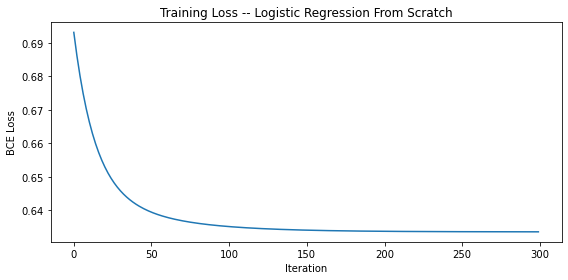

In [21]:
plt.figure(figsize=(8, 4))
plt.plot(model.loss_history)
plt.xlabel('Iteration')
plt.ylabel('BCE Loss')
plt.title('Training Loss -- Logistic Regression From Scratch')
plt.tight_layout()
plt.show()

## Section 10: Evaluate

In [22]:
predictions = model.predict(X_test)
acc = model.accuracy(y_test, predictions)
cm  = model.confusion_matrix(y_test, predictions)

TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
precision   = TP / (TP + FP) if (TP + FP) > 0 else 0
recall      = TP / (TP + FN) if (TP + FN) > 0 else 0
f1          = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
specificity = TN / (TN + FP) if (TN + FP) > 0 else 0

print(f'Accuracy    : {acc:.4f} ({acc*100:.1f}%)')
print()
print('Confusion Matrix:')
print(f'  [[TN={TN}  FP={FP}]')
print(f'   [FN={FN}  TP={TP}]]')
print()
print(f'Precision   : {precision:.4f}')
print(f'Recall      : {recall:.4f}')
print(f'F1 Score    : {f1:.4f}')
print(f'Specificity : {specificity:.4f}')

Accuracy    : 0.5000 (50.0%)

Confusion Matrix:
  [[TN=38  FP=2]
   [FN=38  TP=2]]

Precision   : 0.5000
Recall      : 0.0500
F1 Score    : 0.0909
Specificity : 0.9500


**Interpreting the confusion matrix:**

- **TN** -- correctly predicted no purchase
- **FP** -- predicted purchase, didn't buy (Type I error)
- **FN** -- predicted no purchase, actually bought (Type II error -- the costly one in marketing)
- **TP** -- correctly predicted a purchase

## Section 11: Sanity Check -- Compare Against sklearn

If the math is right, accuracy should be close to sklearn's.
This is the proof that the implementation is correct, not just plausible-looking.

In [23]:
from sklearn.linear_model import LogisticRegression

sklearn_model = LogisticRegression(max_iter=300)
sklearn_model.fit(X_train, y_train)
sklearn_acc = sklearn_model.score(X_test, y_test)

print('=' * 42)
print(f'  Scratch accuracy : {acc:.4f}')
print(f'  Sklearn accuracy : {sklearn_acc:.4f}')
print('=' * 42)
gap = abs(acc - sklearn_acc)
print('  Close enough!' if gap < 0.05 else f'  Gap of {gap:.4f} -- try higher n_iters or different lr')

  Scratch accuracy : 0.5000
  Sklearn accuracy : 0.5000
  Close enough!


## Key Takeaways

| Concept | What It Means |
|---|---|
| **Sigmoid** | Maps raw score to probability between 0 and 1 |
| **BCE Loss** | Penalises confident wrong predictions very heavily |
| **0.5 Threshold** | Default decision boundary -- adjustable for precision/recall tradeoff |
| **Confusion Matrix** | Shows where the model fails -- more informative than accuracy alone |